<font size = "4">

- This is another example showing the difference between "long" and "wide" formats, and why the long format may be advantageous

- This creates a DataFrame with (made-up) data for 3 cities: New York City, Los Angeles, and Chicago.

- For each city, we collect the temperature, level of precipitation, and wind speed for Jan. 1-Jan. 5, 2025. (Again the data is made up)

- We create the DataFrame in "Wide" format


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_wide = pd.DataFrame({
    "date": pd.date_range("2025-01-01", periods=5, freq="D"),
    "temp_NY": [30, 28, 29, 32, 31],
    "temp_LA": [60, 61, 60, 59, 58],
    "temp_CHI": [25, 24, 26, 27, 28],
    "precip_NY": [0.1, 0.0, 0.0, 0.2, 0.0],
    "precip_LA": [0.0, 0.0, 0.0, 0.1, 0.1],
    "precip_CHI": [0.2, 0.1, 0.0, 0.0, 0.3],
    "wind_NY": [12, 10, 8, 14, 9],
    "wind_LA": [6, 7, 5, 6, 6],
    "wind_CHI": [18, 17, 19, 20, 21]
})

display(df_wide)

,date,temp_NY,temp_LA,temp_CHI,precip_NY,precip_LA,precip_CHI,wind_NY,wind_LA,wind_CHI
0,2025-01-01,30,60,25,0.1,0.0,0.2,12,6,18
1,2025-01-02,28,61,24,0.0,0.0,0.1,10,7,17
2,2025-01-03,29,60,26,0.0,0.0,0.0,8,5,19
3,2025-01-04,32,59,27,0.2,0.1,0.0,14,6,20
4,2025-01-05,31,58,28,0.0,0.1,0.3,9,6,21


We'll do 2 calculations using the wide format:

- Compute the average precipitation for each city over these five days

- Plot the wind speed of all three cities on the same figure

In [2]:
# average precipitation by city

precip_cols = ["precip_NY", "precip_LA", "precip_CHI"]
df_wide[precip_cols].mean()

precip_NY     0.06
precip_LA     0.04
precip_CHI    0.12
dtype: float64

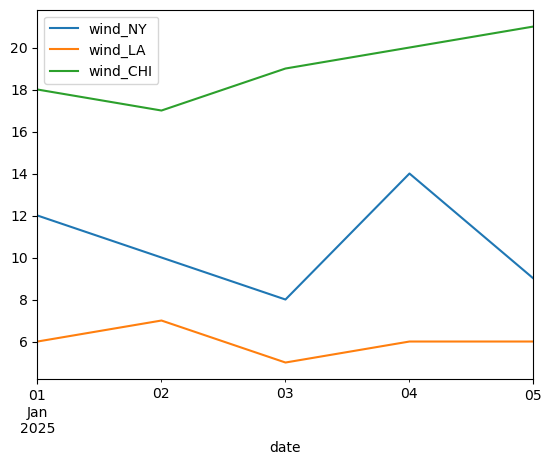

In [3]:
# plot all 3 cities wind speed on same figure

df_wide2 = (df_wide[["date", "wind_NY", "wind_LA", "wind_CHI"]].
    set_index("date").plot())

plt.show()

- The code above is not *scalable*. What happens if our dataset is expanded to include the top 50 cities in the U.S. (in terms of population)?

- In this case, we would need to write *a lot* of strings. For average precipitation:

```python
# average precipitation

precip_cols = ["precip_NY", "precip_LA", "precip_CHI",        "precip_HOU", "precip_PHX", "precip_PHI", "precip_SATX",    "precip_SD", "precip_DTX", "precip_JAX", ...]
# 40 more string to go...

df_wide[precip_cols].mean()
```

and for plotting:

```python
df_wide2 = (df_wide[["date", "wind_NY", "wind_LA", "wind_CHI", "wind_HOU", "wind_PHX", "wind_PHI", "wind_SATX", "wind_SD", "wind_DTX", "wind_JAX", ...]].
set_index("date").plot())
# 40 strings omitted...
```

- Once we convert to "Long" format, we can write much shorter code without having to manually type all the cities in the dataset

- Converting to Long format requires a little more work than the financial data from Lecture 19 though.

**Step 1:** Use the ``.melt`` method to convert to long format.

In [4]:
# "melt" dataset to convert to long format
df_long = df_wide.melt(id_vars="date", var_name="measurement", 
    value_name="value")
display(df_long)

,date,measurement,value
0,2025-01-01,temp_NY,30.0
1,2025-01-02,temp_NY,28.0
2,2025-01-03,temp_NY,29.0
3,2025-01-04,temp_NY,32.0
4,2025-01-05,temp_NY,31.0
5,2025-01-01,temp_LA,60.0
6,2025-01-02,temp_LA,61.0
7,2025-01-03,temp_LA,60.0
8,2025-01-04,temp_LA,59.0
9,2025-01-05,temp_LA,58.0


**Step 2:** The "measurement" column still has the form (weather variable)_(city). We would like to *split* this into two columns, one for the variable, one for the city.

In [5]:
# Split measurement column:
# "temp_NY" → variable="temp", city="NY"

# Take part of string BEFORE the underscore "_" and assign it
# to a new column called "variable".
df_long["variable"] = df_long["measurement"].str.split("_").str[0]

# Take part of string AFTER the underscore "_" and assign it
# to a new column called "city".
df_long["city"] = df_long["measurement"].str.split("_").str[1]

# Remove the measurement column, since we don't need it anymore
df_long = df_long.drop(columns="measurement")

display(df_long)

,date,value,variable,city
0,2025-01-01,30.0,temp,NY
1,2025-01-02,28.0,temp,NY
2,2025-01-03,29.0,temp,NY
3,2025-01-04,32.0,temp,NY
4,2025-01-05,31.0,temp,NY
5,2025-01-01,60.0,temp,LA
6,2025-01-02,61.0,temp,LA
7,2025-01-03,60.0,temp,LA
8,2025-01-04,59.0,temp,LA
9,2025-01-05,58.0,temp,LA


We'll do the same 2 calculations using the *long* format:

- Compute the average precipitation for each city over these five days

- Plot the wind speed of all three cities on the same figure

The two code cells below could be used **with no changes** even if the dataset included 50 cities (or 75 cities, or 400 cities).

In [6]:
# average precipitation by city

df_long.query("variable == 'precip'").groupby("city")["value"].mean()

city
CHI    0.12
LA     0.04
NY     0.06
Name: value, dtype: float64

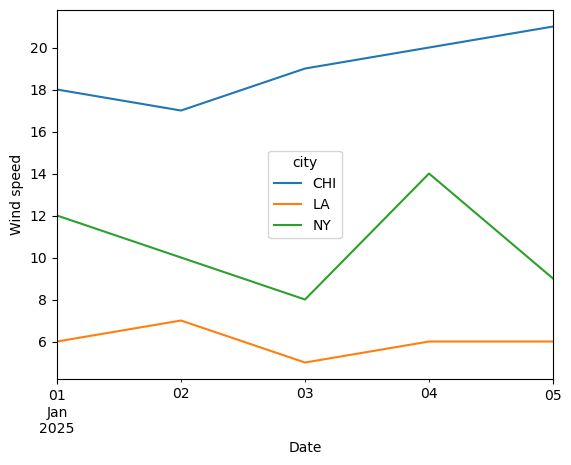

In [7]:
# plot all 3 cities wind speed on same figure

df_wind = (
    df_long[df_long["variable"] == "wind"]
    .pivot(index="date", columns="city", values="value")
)

df_wind.plot() 

plt.ylabel("Wind speed")
plt.xlabel("Date")
plt.show()

We can convert back to the original "Wide" format, but it also requires two steps.

**Step 1:** Use the ``.pivot`` method to convert to Wide format. The columns are tuples (pairs) with the form (weather variable, city).

(This isn't the original format, but it might be good enough.)

In [8]:
df_back2wide = df_long.pivot(
    index="date",
    columns=["variable", "city"],
    values="value"
)

display(df_back2wide)

variable    temp             precip            wind           
city          NY    LA   CHI     NY   LA  CHI    NY   LA   CHI
date                                                          
2025-01-01  30.0  60.0  25.0    0.1  0.0  0.2  12.0  6.0  18.0
2025-01-02  28.0  61.0  24.0    0.0  0.0  0.1  10.0  7.0  17.0
2025-01-03  29.0  60.0  26.0    0.0  0.0  0.0   8.0  5.0  19.0
2025-01-04  32.0  59.0  27.0    0.2  0.1  0.0  14.0  6.0  20.0
2025-01-05  31.0  58.0  28.0    0.0  0.1  0.3   9.0  6.0  21.0

**Step 2:** Loop over the column names, which are pairs, and convert them to a single formatted string using the ``f`` prefix.

(This also uses something called "list comprehension")

In [9]:
# Example of formatted strings

subject = "DATASCI"
course_no = 151

print(f"Welcome to {subject}-{course_no}!")

Welcome to DATASCI-151!


In [10]:

df_back2wide.columns = [
    f"{var}_{city}" for var, city in df_back2wide.columns
]

# uncomment to reset the index, and make "date" a normal column
# df_back2wide = df_back2wide.reset_index()

display(df_back2wide)

,temp_NY,temp_LA,temp_CHI,precip_NY,precip_LA,precip_CHI,wind_NY,wind_LA,wind_CHI
date,,,,,,,,,
2025-01-01,30.0,60.0,25.0,0.1,0.0,0.2,12.0,6.0,18.0
2025-01-02,28.0,61.0,24.0,0.0,0.0,0.1,10.0,7.0,17.0
2025-01-03,29.0,60.0,26.0,0.0,0.0,0.0,8.0,5.0,19.0
2025-01-04,32.0,59.0,27.0,0.2,0.1,0.0,14.0,6.0,20.0
2025-01-05,31.0,58.0,28.0,0.0,0.1,0.3,9.0,6.0,21.0


Here's a version that uses a more familiar looking for loop. It is completely equivalent to the cell above.

In [11]:
# Step 1 - use .pivot

df_back2wide = df_long.pivot(
    index="date",
    columns=["variable", "city"],
    values="value"
)


# Step 2 - change pairs back to strings.
col_renamed = []
for var, city in df_back2wide.columns:
    col_renamed.append(f"{var}_{city}")

df_back2wide.columns = col_renamed

display(df_back2wide)


,temp_NY,temp_LA,temp_CHI,precip_NY,precip_LA,precip_CHI,wind_NY,wind_LA,wind_CHI
date,,,,,,,,,
2025-01-01,30.0,60.0,25.0,0.1,0.0,0.2,12.0,6.0,18.0
2025-01-02,28.0,61.0,24.0,0.0,0.0,0.1,10.0,7.0,17.0
2025-01-03,29.0,60.0,26.0,0.0,0.0,0.0,8.0,5.0,19.0
2025-01-04,32.0,59.0,27.0,0.2,0.1,0.0,14.0,6.0,20.0
2025-01-05,31.0,58.0,28.0,0.0,0.1,0.3,9.0,6.0,21.0
